In [18]:
import numpy as np
import copy
import math
import matplotlib.pyplot as plt

**Training datas for logistic regression**

In [44]:
X_train_logistic = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])  #(m,n)
y_train_logistic = np.array([0, 0, 0, 1, 1, 1])         #(m,)
pos = y_train_logistic == 1
neg = y_train_logistic == 0

**Training datas for linear regression**

In [6]:
X_train_linear = np.array([[1, 1],
                           [2, 1],
                           [2, 2],
                           [3, 2],
                           [4, 2],
                           [4, 3],
                           [5, 3],
                           [6, 3]])   # (m,2)

y_train_linear = np.array([3.0,
                           3.8,
                           4.5,
                           5.2,
                           6.0,
                           6.8,
                           7.5,
                           8.5])     # (m,)

**Sigmoid function**

In [28]:
def sigmoid_function(x):
    return 1 / (1 + np.exp(-x))
    

**Cost function of linear regression model**

In [29]:
def cost_function_linear(x,y,w,b,lambda_):
    m,n = x.shape
    unregularized_cost = 0
    penalty = 0
    for i in range(m):
        pred_y = np.dot(x[i],w) + b
        error = pred_y - y[i]
        squared_error = np.square(error)
        unregularized_cost+=squared_error
    for j in range(n):
        penalty+=np.square(w[j])
    cost = unregularized_cost/2*m 
    reg_cost = penalty * (lambda_/2*m)
    total_cost = cost + reg_cost
    return total_cost
    
    
        
        

**Cost function of logistic regression model**

In [30]:
def cost_function_logistic(x,y,w,b,sigmoid_function,lambda_):
    m,n = x.shape
    unregularized_cost = 0
    penalty = 0
    for i in range(m):
        pred_y = sigmoid_function(np.dot(x[i],w) + b)
        unregularized_cost+= -y[i] * np.log(pred_y) - (1-y[i]) * np.log(1 -pred_y)
    for j in range(n):
        penalty+=np.square(w[j])
    cost = unregularized_cost/m 
    reg_cost = penalty * (lambda_/2*m)  #regularized cost for weights
    total_cost = cost + reg_cost
    return total_cost
    
    
        
        

**Gradient of linear regression with regularization** 

In [31]:
def gradient_linear(x,y,w,b,lambda_):
    m,n = x.shape
    dj_dw = np.zeros(n)  #the number of partial derivatives must match with the number of weights and these number of weights must match with the number of training features 
    dj_db = 0
    for i in range(m):
        y_pred = np.dot(x[i],w) + b
        error = y_pred - y[i]
        for j in range(n):
            dj_dw[j] += error * x[i,j]  #partial derivative of the cost function with respect to the weight of the input features
        dj_db += error  
    dj_dw = dj_dw / m
    dj_db = dj_db / m
    reg_gradient = 0
    for j in range(n):
        dj_dw[j] += (lambda_/m) * w[j]
    return dj_dw,dj_db    
   
    
        
        

**Gradient of logistic regression with regularization**

In [32]:
def gradient_logistic(x,y,w,b,lambda_):
    m,n = x.shape
    dj_dw = np.zeros(n)
    dj_db = 0
    for i in range(m):
        y_pred = np.dot(x[i],w) + b
        sigmoid = sigmoid_function(y_pred)  #the logistic function is with the sigmoid
        error = sigmoid - y[i]
        for j in range(n):
            dj_dw[j]+=error * x[i,j]
        dj_db+=error
    dj_dw = dj_dw / m
    dj_db = dj_db / m
    #with regularization
    for j in range(n):
        dj_dw[j]+= (lambda_/m) * w[j]
    #we dont regularize with bias as the regularization with bias value doesnot make much difference at all
    return dj_dw,dj_db
    

**Gradient Descent of linear regression model with regularization**

In [33]:
def gradient_descent(w_init,b_init,x,y,gradient,cost_function,lambda_,alpha,iterations):
    w = copy.deepcopy(w_init)
    b= b_init
    cost_history = []
    iter_history = []
    for i in range(iterations):
        dj_dw,dj_db = gradient(x,y,w,b,lambda_)
        w= w - (alpha * dj_dw)
        b = b -  (alpha * dj_db)
        cost = cost_function(x,y,w,b,lambda_)
        if i % math.ceil(iterations/10) == 0:
            cost_history.append(cost)
            iter_history.append(i)
    return w,b,cost_history,iter_history
m,n = X_train_linear.shape
w_init = np.zeros(n)    
b_init = 0 
alpha = 0.01
iterations = 10000
lambda_ = 0.7
final_w,final_b,cost_history,iter_history=gradient_descent(w_init,b_init,X_train_linear,y_train_linear,gradient_linear,cost_function_linear,lambda_,alpha,iterations)
           
        
    

**Learning curve of Gradient Descent of linear regression model with regularization**

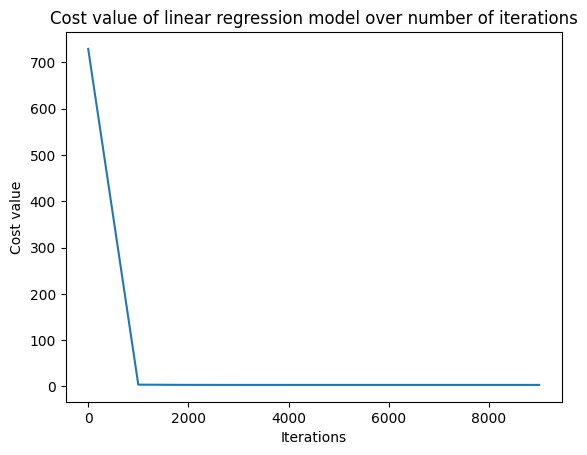

In [34]:
plt.plot(iter_history,cost_history)
plt.xlabel('Iterations')
plt.ylabel('Cost value')
plt.title('Cost value of linear regression model over number of iterations')
plt.show()

**Gradient Descent of logistic regression model with regularization**

In [41]:
def gradient_descent_logistic(x,y,w_init,b_init,cost_function,gradient,lambda_,alpha,iterations):
    w = copy.deepcopy(w_init)
    b = b_init
    cost_hist = []
    iter_hist = []
    for i in range(iterations):
        dj_dw,dj_db = gradient(x,y,w,b,lambda_)
        w = w - (alpha * dj_dw)
        b = b - (alpha * dj_db)
        cost = cost_function(x,y,w,b,sigmoid_function,lambda_)
        if i % math.ceil(iterations/10) == 0:
            cost_hist.append(cost)
            iter_hist.append(i)
    return w,b,cost_hist,iter_hist
w_init = np.zeros(n)     #initial weight
b_init = 0   #initial bias
alpha = 0.01  #learning rate 
iterations = 10000
lambda_ = 0.7   #penalty on the weights of the model   
log_w,log_b,cost_lhist,iter_lhist = gradient_descent_logistic(X_train_logistic,y_train_logistic,w_init,b_init,cost_function_logistic,gradient_logistic,lambda_,alpha,iterations)    
log_y_pred = sigmoid_function(np.dot(X_train_logistic[0],log_w) + log_b)
print(f'The predicted y value for {X_train_logistic[0]} is: {log_y_pred}')
print(f'The actual y value for this x is: {y_train_logistic[0]}')        


The predicted y value for [0.5 1.5] is: 0.28491308014561134
The actual y value for this x is: 0


**Plotting the logistic Regression Model**

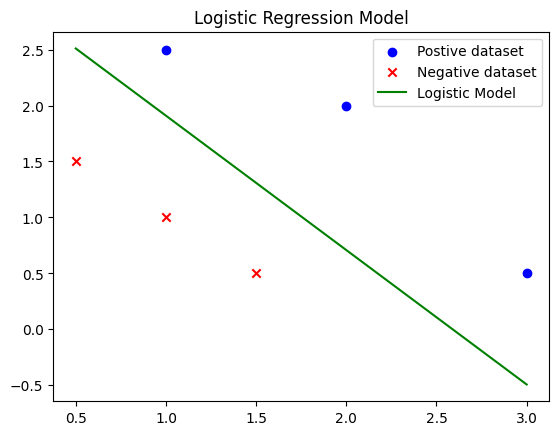

In [50]:
#plotting the original dataset
plt.scatter(X_train_logistic[pos,0],X_train_logistic[pos,1],marker='o',c='b',label='Postive dataset')
plt.scatter(X_train_logistic[neg,0],X_train_logistic[neg,1],marker='x',c='r',label='Negative dataset')
#plotting the decision boundary
x1 = np.linspace(X_train_logistic.min(),X_train_logistic.max())
x2 = (- log_b - (log_w[0] * x1))/ log_w[1]
plt.plot(x1,x2,c='g',label='Logistic Model')

plt.title('Logistic Regression Model')
plt.legend()
plt.show()


